AI Project - Sem IV - Handwritten Digit Recognition.

Team Members:
Dhruv Goyal - 102303099 - 2C14 - COE
Jeevant Verma - 102303100 - 2C14 - COE
Libraries imported successfully.
Loading the EMNIST dataset.
Dataset loaded successfully.
Preprocessing the data.
Data preprocessing complete.
Handling missing values.
Missing values handled successfully.
Helper functions defined.

Training K-Nearest Neighbors (KNN).

Running KNN with k=3
KNN (k=3) Accuracy: 98.46%


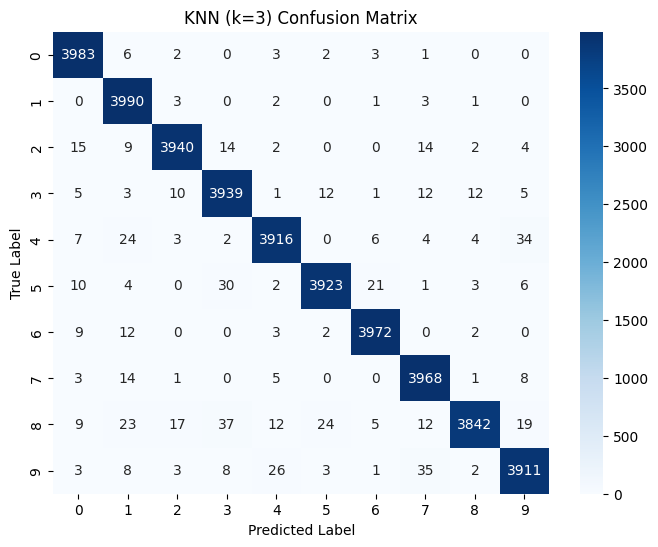


Running KNN with k=5
KNN (k=5) Accuracy: 98.34%


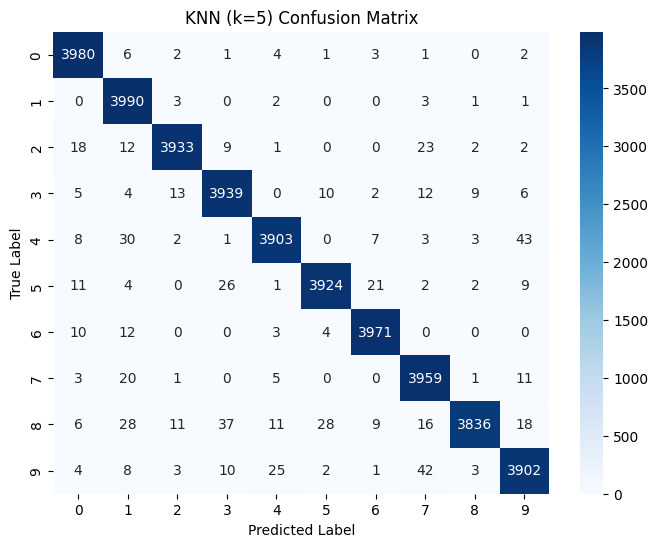


Training Logistic Regression.

Running Logistic Regression with max_iter=100


C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression (max_iter=100) Accuracy: 94.18%


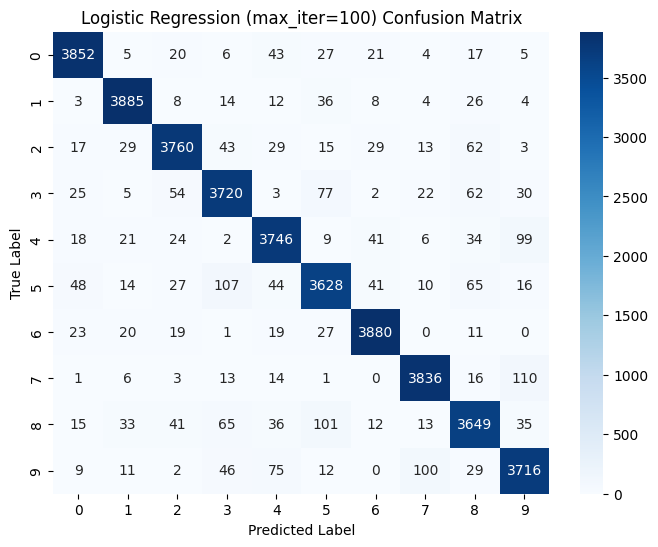


Running Logistic Regression with max_iter=200


C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression (max_iter=200) Accuracy: 94.21%


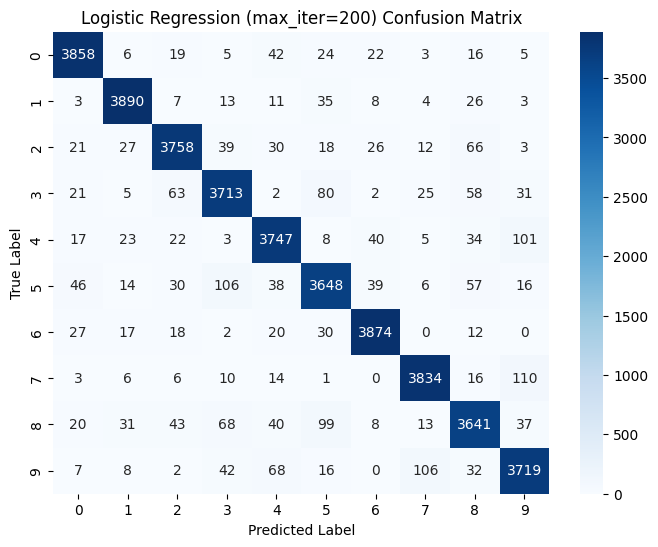


Training Support Vector Classifier (SVM).

Running SVM with C=0.1
SVM (C=0.1) Accuracy: 97.97%


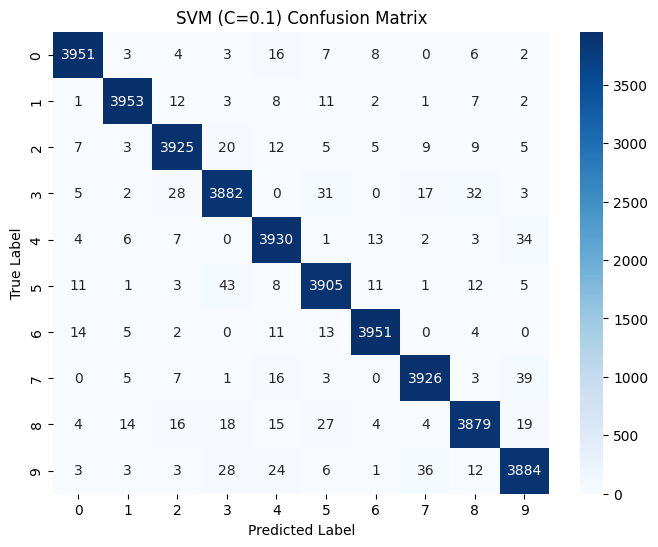


Running SVM with C=1
SVM (C=1) Accuracy: 98.99%


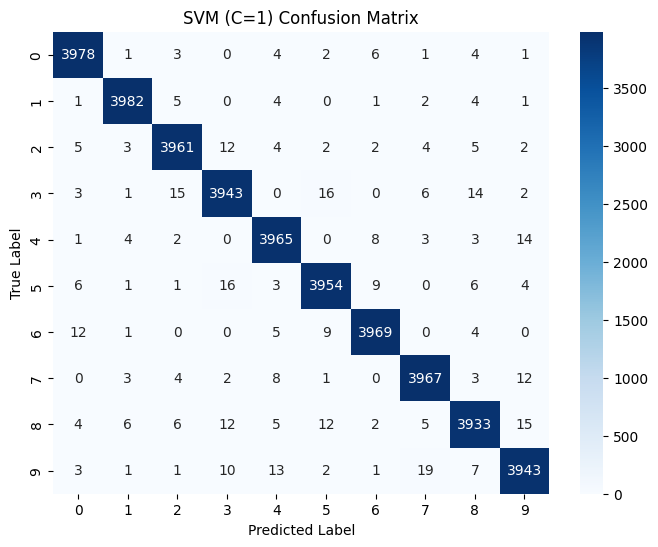


Training Decision Tree.

Running Decision Tree with max_depth=10
Decision Tree (max_depth=10) Accuracy: 89.83%


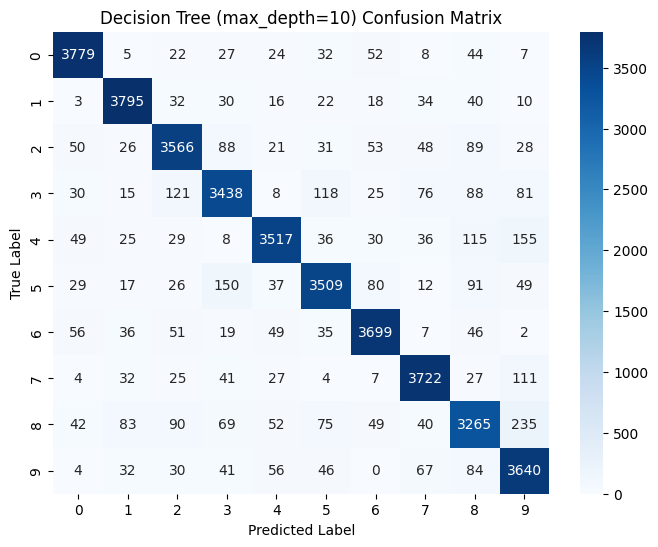


Running Decision Tree with max_depth=15
Decision Tree (max_depth=15) Accuracy: 92.69%


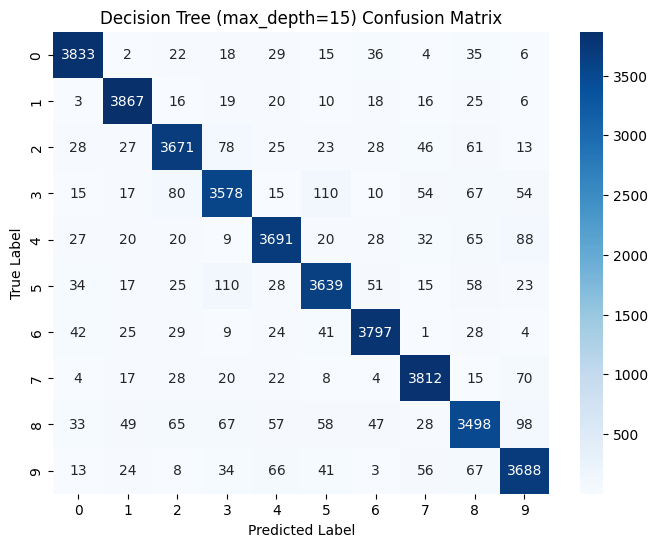


Training Random Forest.

Running Random Forest with n_estimators=50
Random Forest (n_estimators=50) Accuracy: 98.11%


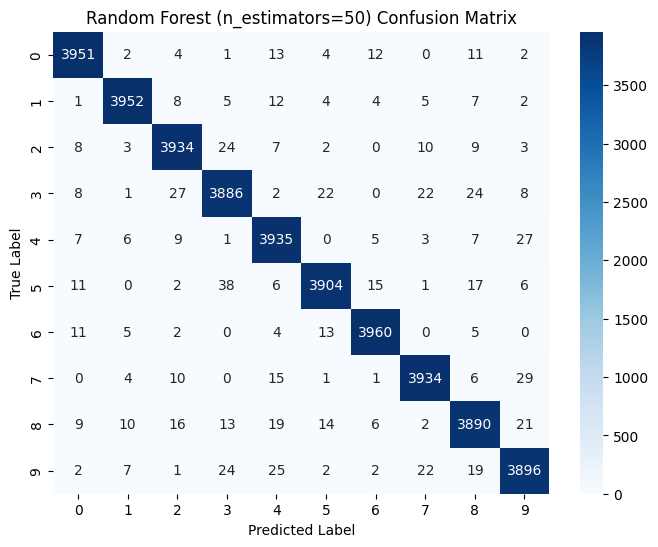


Running Random Forest with n_estimators=100
Random Forest (n_estimators=100) Accuracy: 98.19%


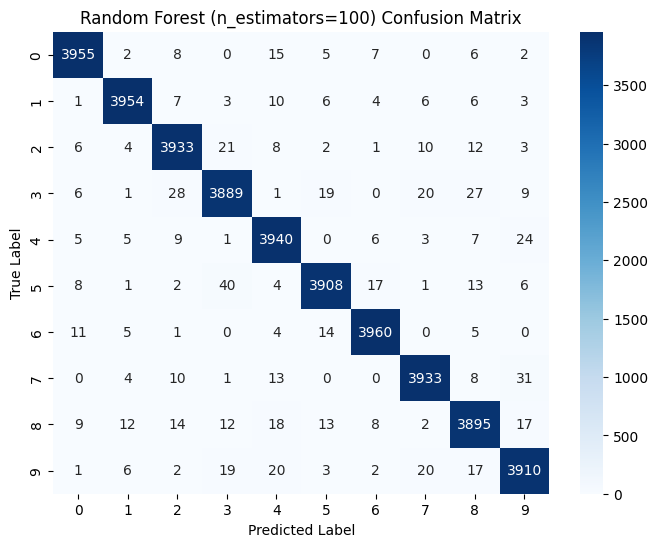


Training XGBoost.

Running XGBoost with learning_rate=0.1
XGBoost (learning_rate=0.1) Accuracy: 98.09%


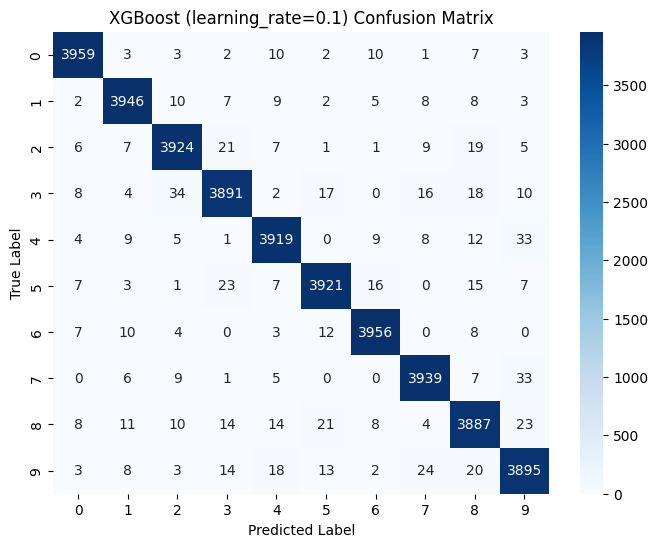


Running XGBoost with learning_rate=0.2
XGBoost (learning_rate=0.2) Accuracy: 98.62%


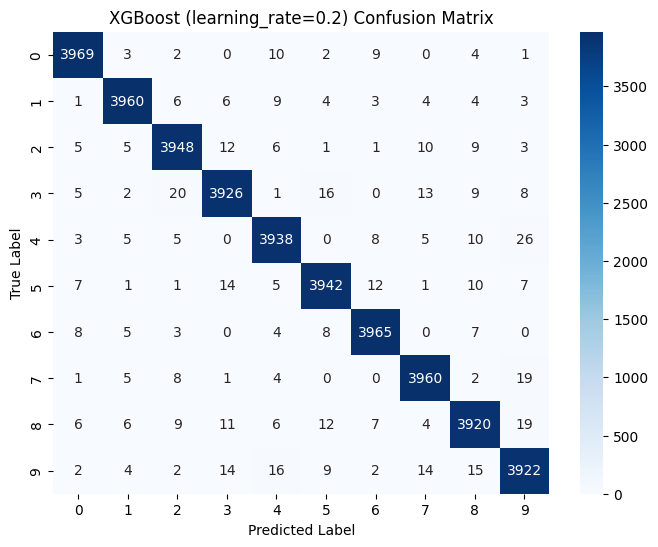


Model Performance Summary:
KNN (k=3): 98.46%
KNN (k=5): 98.34%
Logistic Regression (max_iter=100): 94.18%
Logistic Regression (max_iter=200): 94.21%
SVM (C=0.1): 97.97%
SVM (C=1): 98.99%
Decision Tree (max_depth=10): 89.83%
Decision Tree (max_depth=15): 92.69%
Random Forest (n_estimators=50): 98.11%
Random Forest (n_estimators=100): 98.19%
XGBoost (learning_rate=0.1): 98.09%
XGBoost (learning_rate=0.2): 98.62%


['xgb_model.pkl']

In [1]:
print("AI Project - Sem IV - Handwritten Digit Recognition.")
print("""
Team Members:
Dhruv Goyal - 102303099 - 2C14 - COE
Jeevant Verma - 102303100 - 2C14 - COE""")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer

print("Libraries imported successfully.")

print("Loading the EMNIST dataset.")
train_data = pd.read_csv('emnist-digits-train.csv', header=None, on_bad_lines='skip')
test_data = pd.read_csv('emnist-digits-test.csv', header=None, on_bad_lines='skip')
print("Dataset loaded successfully.")

print("Preprocessing the data.")

x_train = train_data.iloc[:, 1:].values.reshape(-1, 28, 28).astype('float32') / 255.0
y_train = train_data.iloc[:, 0].values
x_test = test_data.iloc[:, 1:].values.reshape(-1, 28, 28).astype('float32') / 255.0
y_test = test_data.iloc[:, 0].values

x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

print("Data preprocessing complete.")

print("Handling missing values.")

imputer = SimpleImputer(strategy='mean')

x_train_flat_imputed = imputer.fit_transform(x_train_flat)
x_test_flat_imputed = imputer.transform(x_test_flat)

print("Missing values handled successfully.")

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("Helper functions defined.")

print("\nTraining K-Nearest Neighbors (KNN).")

model_performance = {}
knn_variations = [3, 5]
for k in knn_variations:
    print(f"\nRunning KNN with k={k}")
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_flat_imputed, y_train)
    y_pred_knn = knn.predict(x_test_flat_imputed)
    knn_accuracy = accuracy_score(y_test, y_pred_knn)
    print(f"KNN (k={k}) Accuracy: {knn_accuracy * 100:.2f}%")
    model_performance[f'KNN (k={k})'] = knn_accuracy * 100  # Store accuracy in percentage
    plot_confusion_matrix(y_test, y_pred_knn, f"KNN (k={k}) Confusion Matrix")

print("\nTraining Logistic Regression.")

log_reg_variations = [100, 200]
for max_iter in log_reg_variations:
    print(f"\nRunning Logistic Regression with max_iter={max_iter}")
    log_reg = LogisticRegression(max_iter=max_iter)
    log_reg.fit(x_train_flat_imputed, y_train)
    y_pred_lr = log_reg.predict(x_test_flat_imputed)
    lr_accuracy = accuracy_score(y_test, y_pred_lr)
    print(f"Logistic Regression (max_iter={max_iter}) Accuracy: {lr_accuracy * 100:.2f}%")
    model_performance[f'Logistic Regression (max_iter={max_iter})'] = lr_accuracy * 100  # Store accuracy in percentage
    plot_confusion_matrix(y_test, y_pred_lr, f"Logistic Regression (max_iter={max_iter}) Confusion Matrix")

print("\nTraining Support Vector Classifier (SVM).")

svm_variations = [0.1, 1]
for C in svm_variations:
    print(f"\nRunning SVM with C={C}")
    svm = SVC(C=C, kernel='rbf')
    svm.fit(x_train_flat_imputed, y_train)
    y_pred_svm = svm.predict(x_test_flat_imputed)
    svm_accuracy = accuracy_score(y_test, y_pred_svm)
    print(f"SVM (C={C}) Accuracy: {svm_accuracy * 100:.2f}%")
    model_performance[f'SVM (C={C})'] = svm_accuracy * 100  # Store accuracy in percentage
    plot_confusion_matrix(y_test, y_pred_svm, f"SVM (C={C}) Confusion Matrix")

print("\nTraining Decision Tree.")

dt_variations = [10, 15]
for max_depth in dt_variations:
    print(f"\nRunning Decision Tree with max_depth={max_depth}")
    dt = DecisionTreeClassifier(max_depth=max_depth)
    dt.fit(x_train_flat_imputed, y_train)
    y_pred_dt = dt.predict(x_test_flat_imputed)
    dt_accuracy = accuracy_score(y_test, y_pred_dt)
    print(f"Decision Tree (max_depth={max_depth}) Accuracy: {dt_accuracy * 100:.2f}%")
    model_performance[f'Decision Tree (max_depth={max_depth})'] = dt_accuracy * 100  # Store accuracy in percentage
    plot_confusion_matrix(y_test, y_pred_dt, f"Decision Tree (max_depth={max_depth}) Confusion Matrix")

print("\nTraining Random Forest.")

rf_variations = [50, 100]  # Number of trees in the forest
for n_estimators in rf_variations:
    print(f"\nRunning Random Forest with n_estimators={n_estimators}")
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rf.fit(x_train_flat_imputed, y_train)
    y_pred_rf = rf.predict(x_test_flat_imputed)
    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    print(f"Random Forest (n_estimators={n_estimators}) Accuracy: {rf_accuracy * 100:.2f}%")
    model_performance[f'Random Forest (n_estimators={n_estimators})'] = rf_accuracy * 100  # Store accuracy in percentage
    plot_confusion_matrix(y_test, y_pred_rf, f"Random Forest (n_estimators={n_estimators}) Confusion Matrix")

print("\nTraining XGBoost.")

xgb_variations = [0.1, 0.2]  # Learning rates
for learning_rate in xgb_variations:
    print(f"\nRunning XGBoost with learning_rate={learning_rate}")
    xgb = XGBClassifier(learning_rate=learning_rate, n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    xgb.fit(x_train_flat_imputed, y_train)
    y_pred_xgb = xgb.predict(x_test_flat_imputed)
    xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
    print(f"XGBoost (learning_rate={learning_rate}) Accuracy: {xgb_accuracy * 100:.2f}%")
    model_performance[f'XGBoost (learning_rate={learning_rate})'] = xgb_accuracy * 100  # Store accuracy in percentage
    plot_confusion_matrix(y_test, y_pred_xgb, f"XGBoost (learning_rate={learning_rate}) Confusion Matrix")

print("\nModel Performance Summary:")
for model, accuracy in model_performance.items():
    print(f"{model}: {accuracy:.2f}%")

import joblib
# Save KNN model
joblib.dump(knn, 'knn_model.pkl')
# Save Logistic Regression model
joblib.dump(log_reg, 'log_reg_model.pkl')
# Save SVM model
joblib.dump(svm, 'svm_model.pkl')
# Save Decision Tree model
joblib.dump(dt, 'dt_model.pkl')
# Save Random Forest model
joblib.dump(rf, 'rf_model.pkl')
# Save XGBoost model
joblib.dump(xgb, 'xgb_model.pkl')

In [1]:
# Save models with protocol=4 for compatibility
joblib.dump(knn, 'knn_model.pkl', protocol=4)
joblib.dump(log_reg, 'log_reg_model.pkl', protocol=4)
joblib.dump(svm, 'svm_model.pkl', protocol=4)
joblib.dump(dt, 'dt_model.pkl', protocol=4)
joblib.dump(rf, 'rf_model.pkl', protocol=4)
# For XGBoost, use save_model() instead of joblib
xgb.save_model('xgb_model.json')  # XGBoost native format

NameError: name 'joblib' is not defined